In [18]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# 1. Muat dataset mentah
df = pd.read_csv("Data/raw_tokopedia_smartphone.csv")
df.head()

,search_keyword,title,price,rating,sold_count
0,iphone 11,APPLE iPhone 15 - iPhone 16 - iPhone 17 - iP...,Rp12.539.000,5.0,10rb+ terjual
1,iphone 11,Iphone 11 64gb / 128Gb / 256Gb Bekas Fullset,Rp3.650.000,4.9,2rb+ terjual
2,iphone 11,iPhone 11 64GB|128GB|256GB second murah bergar...,Rp3.350.000,4.9,1rb+ terjual
3,iphone 11,iPhone 11 pro 64GB Bekas original 100% Mulus f...,Rp4.700.000,4.9,500+ terjual
4,iphone 11,iPhone 11 64GB Original 100% | Mulus Normal Fu...,Rp3.500.000,4.9,750+ terjual


In [20]:
# 2. Bersihkan Harga, Terjual, Rating
def clean_price(val):
    if pd.isna(val): return np.nan
    digits = re.sub(r"[^\d]", "", str(val))
    return int(digits) if digits else np.nan

def clean_sold(val):
    if pd.isna(val): return 0
    s = str(val).lower().replace("terjual", "").replace("+", "").strip()
    if "rb" in s:
        s = s.replace("rb", "").replace(",", ".").strip()
        return int(float(s) * 1000)
    digits = re.sub(r"[^\d]", "", s)
    return int(digits) if digits else 0

df["price_clean"] = df["price"].apply(clean_price)
df["sold_clean"] = df["sold_count"].apply(clean_sold)
df["rating_clean"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0.0)

In [21]:
# 3. Ekstraksi RAM & Storage (ROM)
VALID_RAM = [3, 4, 6, 8, 12, 16, 18, 24]
VALID_STORAGE = [32, 64, 128, 256, 512, 1024]

def extract_memory(title):
    t = str(title).upper()
    ram, storage = np.nan, np.nan

    # Pola umum: 8/256, 8GB/256GB, 8+8/256, 8+8GB/128GB
    slash_match = re.search(r'(\d+)(?:\+\d+)?\s*(?:GB)?\s*/\s*(\d+)\s*(?:GB|TB)?', t)
    if slash_match:
        r_candidate = int(slash_match.group(1))
        s_candidate = int(slash_match.group(2))
        if s_candidate == 1: # Kasus varian 1TB
            s_candidate = 1024
        if r_candidate in VALID_RAM: ram = r_candidate
        if s_candidate in VALID_STORAGE: storage = s_candidate

    # Fallback RAM jika belum ketemu (misal: "RAM 8GB" atau "8GB RAM")
    if pd.isna(ram):
        ram_match = re.search(r'(?:RAM\s*(\d+)|(\d+)\s*GB\s*RAM)', t)
        if ram_match:
            r_candidate = int(ram_match.group(1) or ram_match.group(2))
            if r_candidate in VALID_RAM: ram = r_candidate

    # Fallback Storage jika belum ketemu (misal: "ROM 256GB" atau "256GB")
    if pd.isna(storage):
        rom_match = re.search(r'(?:ROM\s*(\d+)|(\d+)\s*(?:GB|TB))', t)
        if rom_match:
            s_candidate = int(rom_match.group(1) or rom_match.group(2))
            if s_candidate == 1:
                s_candidate = 1024
            if s_candidate in VALID_STORAGE and s_candidate != ram:
                storage = s_candidate

    return pd.Series([ram, storage], index=["ram_gb", "storage_gb"])

df[["ram_gb", "storage_gb"]] = df["title"].apply(extract_memory)

In [22]:
# 4. Ekstraksi Brand
def extract_brand(title):
    t = str(title).lower()
    brands = {
        "APPLE": ["iphone", "apple"],
        "SAMSUNG": ["samsung"],
        "XIAOMI": ["xiaomi", "redmi"],
        "POCO": ["poco"],
        "INFINIX": ["infinix"],
        "TECNO": ["tecno"],
        "ITEL": ["itel"],
        "OPPO": ["oppo"],
        "VIVO": ["vivo", "iqoo"],
        "REALME": ["realme"],
        "ASUS": ["asus", "rog"]
    }
    for brand, aliases in brands.items():
        if any(alias in t for alias in aliases):
            return brand
    return "OTHER"

df["brand"] = df["title"].apply(extract_brand)

In [23]:
# 5. Price Tier
bins = [0, 2_000_000, 5_000_000, 10_000_000, np.inf]
labels = ["Entry-Level (<2M)", "Mid-Range (2M-5M)", "Upper Mid (5M-10M)", "Flagship (>10M)"]
df["price_tier"] = pd.cut(df["price_clean"], bins=bins, labels=labels)

In [24]:
# 6. Filter baris valid & simpan
df_clean = df.dropna(subset=["price_clean"]).drop_duplicates(subset=["title", "price_clean"])
df_clean.to_csv("Data/clean_tokopedia_smartphone.csv", index=False)

print(f"Total baris bersih: {len(df_clean)}")
print(f"RAM terdeteksi: {df_clean['ram_gb'].notna().sum()} unit")
print(f"Storage terdeteksi: {df_clean['storage_gb'].notna().sum()} unit")

Total baris bersih: 2259
RAM terdeteksi: 1373 unit
Storage terdeteksi: 1859 unit


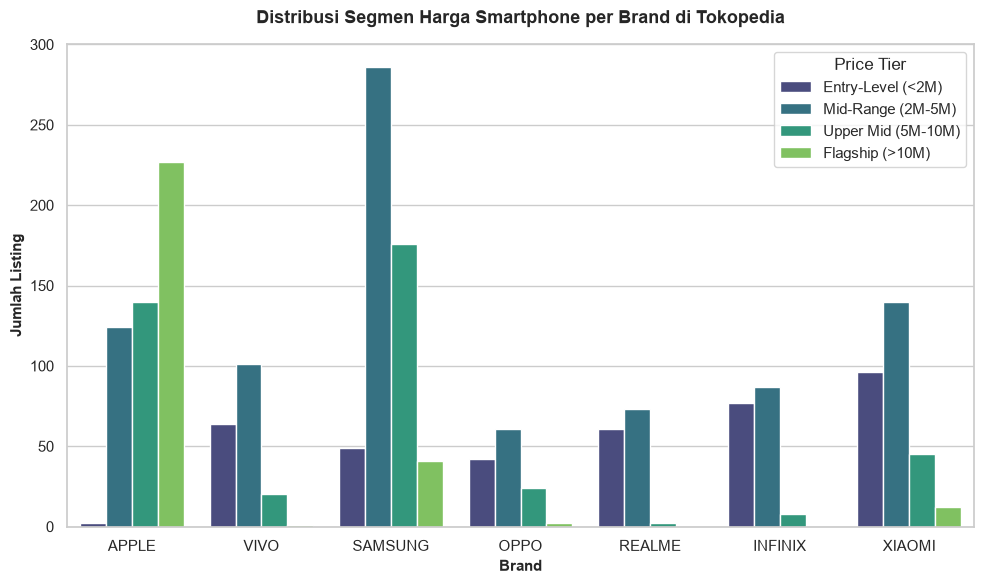

In [ ]:
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid")

# Data preparation
tier_order = ["Entry-Level (<2M)", "Mid-Range (2M-5M)", "Upper Mid (5M-10M)", "Flagship (>10M)"]
top_brands = [b for b in df_clean["brand"].value_counts().head(8).index if b != "OTHER"]
df_top = df_clean[df_clean["brand"].isin(top_brands)]

# Plot 1
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(
    data=df_top,
    x="brand",
    hue="price_tier",
    hue_order=tier_order,
    palette="viridis"
)
plt.title("Distribusi Segmen Harga Smartphone per Brand di Tokopedia", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Brand", fontsize=11, fontweight="bold")
plt.ylabel("Jumlah Listing", fontsize=11, fontweight="bold")
plt.legend(title="Price Tier", frameon=True)
plt.tight_layout()


plt.savefig("figures/1_price_tier_distribution.png", dpi=300)
plt.show()

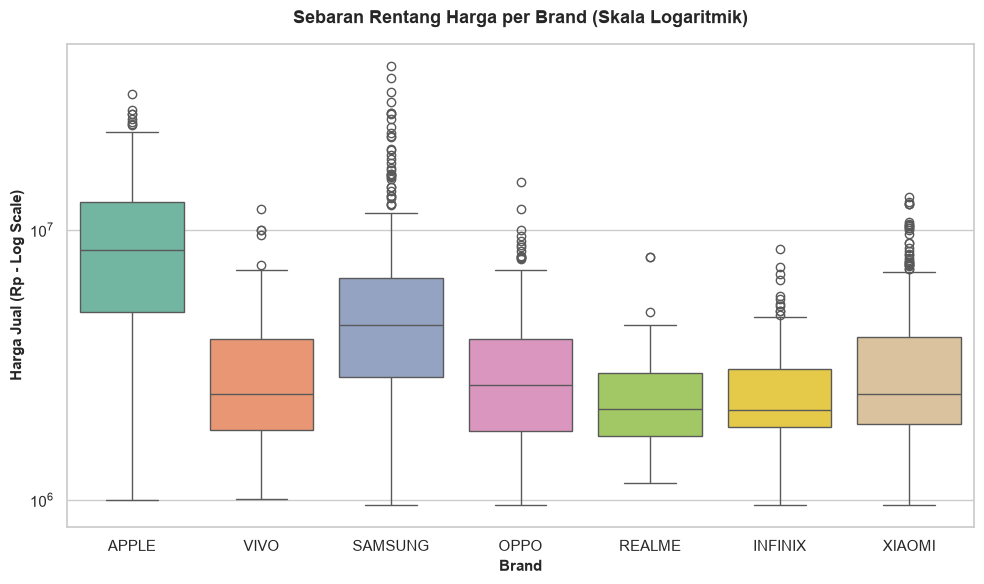

In [27]:
plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(
    data=df_top,
    x="brand",
    y="price_clean",
    hue="brand",
    legend=False,
    palette="Set2"
)
plt.yscale("log")
plt.title("Sebaran Rentang Harga per Brand (Skala Logaritmik)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Brand", fontsize=11, fontweight="bold")
plt.ylabel("Harga Jual (Rp - Log Scale)", fontsize=11, fontweight="bold")
plt.tight_layout()

plt.savefig("figures/2_price_range_boxplot.png", dpi=300)
plt.show()

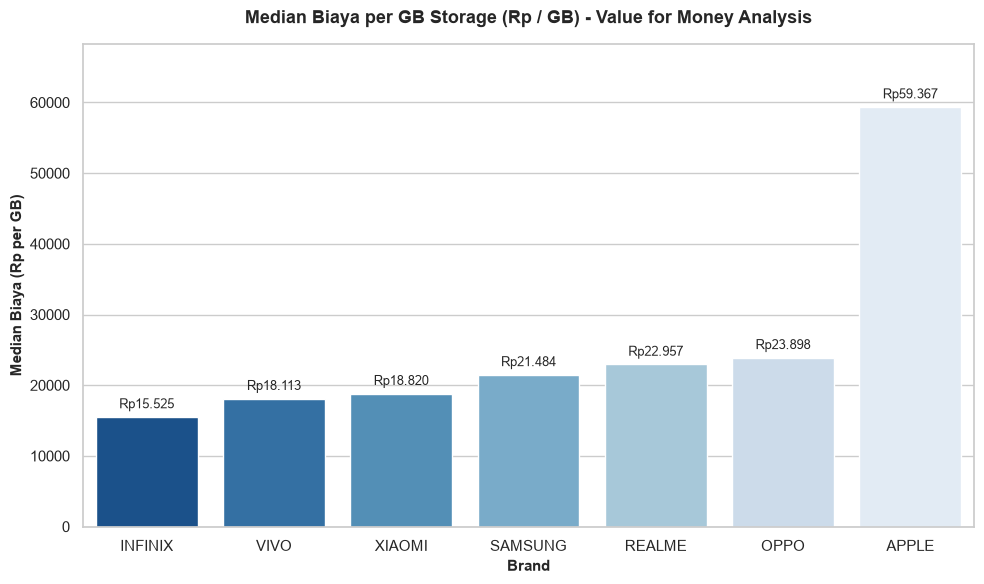

In [30]:
df_storage = df_clean[df_clean["storage_gb"].notna() & (df_clean["storage_gb"] > 0)].copy()
df_storage["price_per_gb"] = df_storage["price_clean"] / df_storage["storage_gb"]

avg_ppgb = (
    df_storage[df_storage["brand"].isin(top_brands)]
    .groupby("brand")["price_per_gb"]
    .median()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax3 = sns.barplot(
    data=avg_ppgb,
    x="brand",
    y="price_per_gb",
    hue="brand",
    legend=False,
    palette="Blues_r"
)
plt.title("Median Biaya per GB Storage (Rp / GB) - Value for Money Analysis", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Brand", fontsize=11, fontweight="bold")
plt.ylabel("Median Biaya (Rp per GB)", fontsize=11, fontweight="bold")

# Beri label ke seluruh batang container
for container in ax3.containers:
    ax3.bar_label(
        container,  # type: ignore
        fmt=lambda x: f"Rp{int(x):,}".replace(",", "."),
        padding=4,
        fontsize=9
    )

# Beri sedikit ruang vertikal di atas agar angka Apple tidak mepet batas atas
ax3.set_ylim(0, avg_ppgb["price_per_gb"].max() * 1.15)

plt.tight_layout()
plt.savefig("figures/3_value_per_gb_storage.png", dpi=300)
plt.show()